In [39]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from seaborn import heatmap
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve


In [40]:
view = pd.read_csv("logisticregdataset.csv")
view

,Study_Hours,Percentage(%),Result
0,1.0,32,0
1,1.5,38,0
2,2.0,42,0
3,2.5,45,0
4,3.0,48,0
5,3.5,51,1
6,4.0,55,1
7,4.5,58,1
8,5.0,62,1
9,5.5,65,1


In [45]:
# Prepare features and target
X = view.drop("Result", axis=1)
y = view["Result"]
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (15, 2)
Target shape: (15,)


In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("✔️ Done")

✔️ Done


In [57]:
model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

conf_matrix_df = pd.DataFrame(conf_matrix, index=["Actual Negative", "Actual Positive"], columns=["Predicted Negative", "Predicted Positive"])

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Confusion Matrix:\n", conf_matrix_df)

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
Confusion Matrix:
                  Predicted Negative  Predicted Positive
Actual Negative                   1                   0
Actual Positive                   0                   2


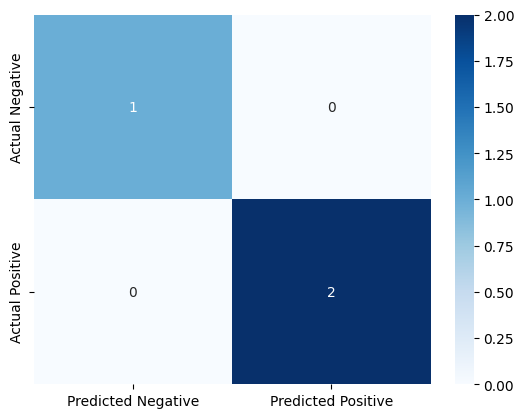

In [56]:
conf_matrix_maps = sns.heatmap(conf_matrix_df, annot=True, fmt="d", cmap="Blues")
plt.show()